In [32]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans

In [13]:
customers = pd.read_csv("customer_segmentation_dataset_5000.csv")

In [14]:
customers.head()

,CustomerID,Gender,Age,AnnualIncome,SpendingScore
0,1,Female,31,94592,97
1,2,Male,22,27314,28
2,3,Male,57,91395,52
3,4,Male,25,27164,21
4,5,Male,64,106062,76


In [15]:
customers = customers.drop(["CustomerID","Gender"],axis=1)

In [16]:
customers

,Age,AnnualIncome,SpendingScore
0,31,94592,97
1,22,27314,28
2,57,91395,52
3,25,27164,21
4,64,106062,76
...,...,...,...
4995,62,142087,88
4996,36,62216,36
4997,43,45044,21
4998,39,114035,61


In [57]:
customers.describe()

,Age,AnnualIncome,SpendingScore,Clusters
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,37.021400,68510.646800,44.210400,1.109200
std,11.781931,38070.586368,26.596955,0.853827
min,18.000000,20003.000000,5.000000,0.000000
25%,28.000000,34576.750000,22.000000,0.000000
50%,35.000000,60197.500000,40.000000,1.000000
75%,45.000000,97420.250000,62.000000,2.000000
max,65.000000,149964.000000,100.000000,2.000000


In [18]:
numeric_columns = ["Age","AnnualIncome","SpendingScore"]

In [21]:
preprocessor = ColumnTransformer(
    transformers=[("num",StandardScaler(),numeric_columns)])

In [24]:
pipeline = Pipeline(steps = [
    ("preprocessor",preprocessor),
    ("model",KMeans(n_clusters=3))])
    

In [25]:
pipeline.fit(customers)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](3,)","['Age','AnnualIncome','SpendingScore']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,3
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transforme

In [27]:
clusters = pipeline.predict(customers)
clusters

array([0, 2, 1, ..., 0, 1, 2], shape=(5000,), dtype=int32)

In [29]:
customers["Clusters"] = clusters

In [30]:
customers.head()

,Age,AnnualIncome,SpendingScore,Clusters
0,31,94592,97,0
1,22,27314,28,2
2,57,91395,52,1
3,25,27164,21,2
4,64,106062,76,1


In [31]:
customers.groupby("Clusters")[["Age","AnnualIncome","SpendingScore"]].mean()

,Age,AnnualIncome,SpendingScore
Clusters,,,
0,39.911970,70669.784674,48.339455
1,50.340278,120588.523148,75.152006
2,26.750588,35144.902588,22.271529


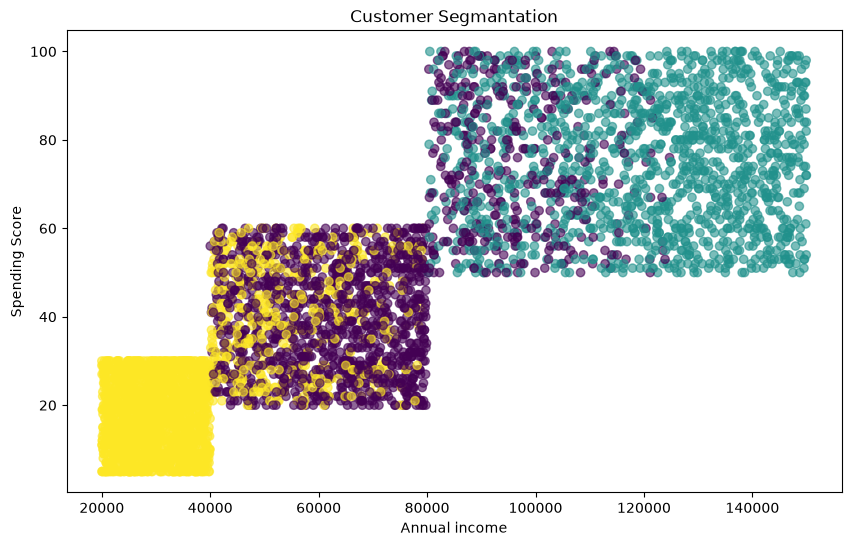

In [37]:
plt.figure(figsize=(10,6))
plt.scatter(
    customers['AnnualIncome'],
    customers['SpendingScore'],
    c=customers["Clusters"],
    alpha = 0.6)
plt.xlabel("Annual income")
plt.ylabel("Spending Score")
plt.title("Customer Segmantation")
plt.show()

In [44]:
# Elbow Method
inertia = []
for k in range(1,11):
    model = KMeans (n_clusters = k, random_state = 42)
    model.fit(customers)
    inertia.append(model.inertia_)

In [45]:
inertia

[7245402596283.995,
 1714931634232.8108,
 684309732239.9841,
 389994021532.6332,
 261362030664.29816,
 183307791734.38464,
 134381990486.44708,
 101136947864.42287,
 76472753152.2435,
 67808467344.00248]

Text(0.5, 1.0, 'Elbow Method')

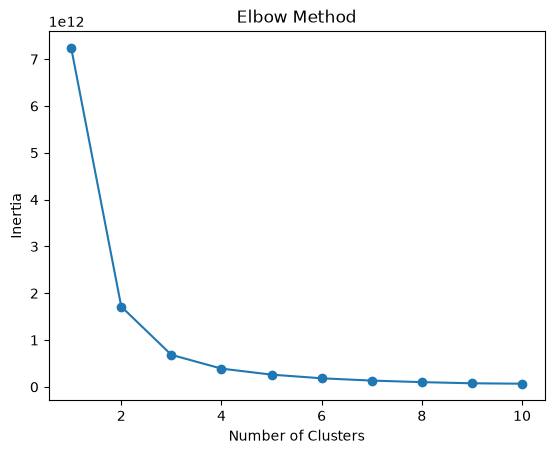

In [46]:
plt.plot(range(1,11),inertia,marker ="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

In [49]:
def get_customer_type(cluster):
    mapping = {
        0:"Regular Shopper",
        1:"Premuium Shopper",
        2:"Budget Shopper",
    }
    return mapping.get(cluster,"Unknown")

In [58]:
new_customer = pd.DataFrame([
    {
        "Age":23,
        "AnnualIncome": 23000,
        "SpendingScore":15
    }])
cluster = pipeline.predict(new_customer)[0]
get_customer_type(cluster)

'Budget Shopper'